### IEEE-14 FDI Attack Analysis:
  - Load IEEE-14 test case and run a power flow
  - Build DC linear measurement model that links power injections to bus angles
  - Create a stealthy attack vector and a random attack for comparison
  - Run a linear least squares state estimatation for each case
  - Plot residuals and state errors


In [45]:
pip install pandapower



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [46]:
pip install seaborn pandas


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [47]:
import numpy as np
import pandapower as pp
import pandas as pd
import pandapower.networks as pn
import seaborn as sns
import pandapower.plotting as pplot
import matplotlib.pyplot as plt

np.random.seed(42)

### Step 1 - Load IEEE-14 bus case

In [48]:
#Load IEEE-14 and run a power flow for an operating point
net = pn.case14()

# Run a power flow to get a steady-state solution 
# And these values act as the "true" system state for later estimation
pp.runpp(net, algorithm='nr', init='dc', calculate_voltage_angles=True)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


### Step 2 - Create simple DC model matrices (B matrix)

In [49]:
# DC power flow assumptions:
# - Voltage magnitudes ≈ 1.0 per unit
# - Reactive power is ignored
# - Active power: P ≈ B * θ  (θ = bus voltage angles)

# Build the susceptance matrix B from line reactances
# Then remove the slack bus to form the reduced matrix H = B_red

In [50]:
#bus setup
buses = net.bus.copy() # Copy bus table and determine number of buses
nb = len(buses)
bus_indices = buses.index.values
bus_id_map = {int(b): i for i, b in enumerate(bus_indices)} # Map bus IDs to 0..nb-1

In [51]:
# Initialise empty susceptance matrix (B)

B = np.zeros((nb, nb)) #empty B matrix
sn_mva = net.sn_mva # system base power to convert ohms -> per unit

# Build B matrix from in-service lines
for _, line in net.line.iterrows():
    if not line.in_service:
        continue # Skip in active lines

    # get sending and receiving bus indices
    fbus = int(line.from_bus); 
    tbus = int(line.to_bus)
    i = bus_id_map[fbus]; 
    j = bus_id_map[tbus]
    
    # Convert line reactance to per-unit
    x_ohm_per_km = line.x_ohm_per_km
    length_km = line.length_km
    x_ohm = x_ohm_per_km * length_km #total ohms
    
    # Convert to per unit reactance
    Vbase = buses.loc[fbus, "vn_kv"] * 1e3 #nominal bus voltage in v
    Zbase = (Vbase**2) / (sn_mva * 1e6)
    
    # Avoid division by zero; if any zero, use a tiny value to avoid crashing.
    if Zbase == 0:
        x_pu = 1e-6
    else:
        x_pu = x_ohm / Zbase if x_ohm != 0 else 1e-6

    # off diagonal lines
    b_ij = -1.0 / x_pu if x_pu != 0 else 0.0

    # Fill symmetric B entries and update diagnols
    B[i, j] += b_ij
    B[j, i] += b_ij
    B[i, i] -= b_ij
    B[j, j] -= b_ij


### Step 3 - Reduce matrix by removing slack bus

In [52]:
# #identify slack bus and use external grid bus if available, otherwise default

# slack_buses = net.ext_grid.bus.values #lists all buses connected to an external grid - typically the slack/reference buses
# if len(net.ext_grid) > 0 else [] 
# if len(slack_buses) == 0:
#     slack = int(bus_indices[0])
# else:
#     slack = int(slack_buses[0]) #if no external grid found (unlikely for IEEE-14) then it defaults to the first bus in the list

# slack_idx = bus_id_map[slack] #convert slack bus ID to internal index
# mask = [i for i in range(nb) if i != slack_idx] #all non-slack buses

# # Identify slack bus
if len(net.ext_grid) > 0:
    slack = int(net.ext_grid.bus.iloc[0])
else:
    slack = int(bus_indices[0])  # fallback (unlikely for IEEE-14)

# Convert slack bus ID to internal index
slack_idx = bus_id_map[slack]

# Mask for non-slack buses
mask = [i for i in range(nb) if i != slack_idx]


In [53]:
# Create the reduced B matrix by removing the slack row/columns. This is H matrix in DC model.
B_red = B[np.ix_(mask, mask)]
H = B_red.copy()


### Step 4 - True state and synthetic measures

In [54]:
# get true bus voltage angles from power flow results
va_deg = net.res_bus.va_degree.values  # angles in degrees
va_rad = np.deg2rad(va_deg)            # convert to radians
x_true = va_rad[mask]                  # non slack bus angles


In [55]:
# gen synthetic measurements w small Gaussian noise
sigma_noise = 0.01  # std of measurment noise
noise = np.random.normal(0, sigma_noise, size=(H.shape[0],))
z = H.dot(x_true) + noise


### Step 5 - Create attacks

In [56]:
# stealth attack build - a = H c (small state change c -> matching measurement change)
c = np.zeros(H.shape[1])

c[0] = 0.02   # small angle change on reduced-state index 0
c[1] = -0.01  # small negative angle change on reduced-state index 1

a_stealth = H.dot(c)  # stealth attack vector

# Non-stealthy random attack
a_random = 0.05 * np.random.randn(H.shape[0])  # larger random values -> likely detectable

# attacked measurement vars
z_attacked_stealth = z + a_stealth
z_attacked_random = z + a_random

### Step 6 - Estimate the state using linear least squares

In [57]:
# Least-squares state estimation, regularisation term is added to prevent numerical issues
def ls_estimate(H, z):
    reg = 1e-8 * np.eye(H.shape[1]) #regularisation matrix (diagonal bias) to avoid numerical instability or singularity issues
    theta_hat = np.linalg.inv(H.T.dot(H) + reg).dot(H.T).dot(z)
    return theta_hat

# Estimate states for no attack, stealth attack, and random attack
theta_no = ls_estimate(H, z)
theta_stealth = ls_estimate(H, z_attacked_stealth)
theta_random = ls_estimate(H, z_attacked_random)

### Step 7 - Compute residuals and state estimation errors

In [58]:
def compute_residuals(H, z, theta_hat):
    return z - H.dot(theta_hat)

r_no = compute_residuals(H, z, theta_no) #baseline residual nnoise
r_stealth = compute_residuals(H, z_attacked_stealth, theta_stealth) #residuals remain close to baseline
r_random = compute_residuals(H, z_attacked_random, theta_random) #residuals increase sharply - clear anomaly

# difference from true state
err_no = theta_no - x_true #shows normal estimation noise (should be near zero)
err_stealth = theta_stealth - x_true #indicates that all angles are systematically shifted - meaning the system believes in a false but self-consistent state.
err_random = theta_random - x_true #large, noisy deviations confirming that random attacks corrupt estimation

### Step 8 - Plot results

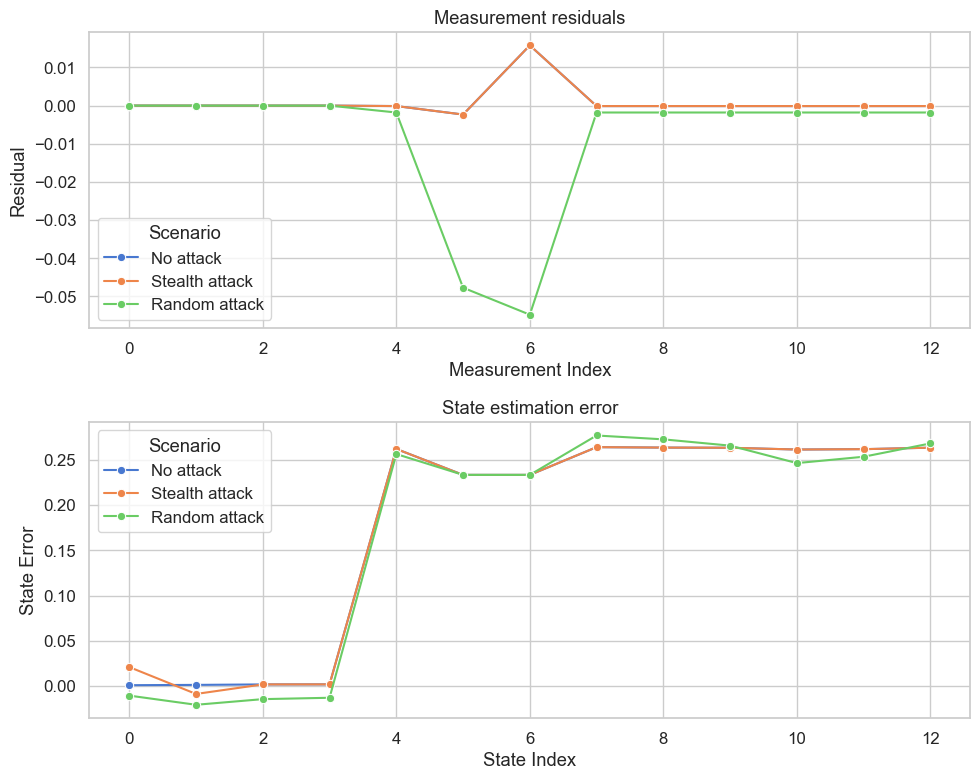

In [59]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# For residuals
df_resid = pd.DataFrame({
    'Measurement Index': np.arange(len(r_no)),
    'No attack': r_no,
    'Stealth attack': r_stealth,
    'Random attack': r_random
}).melt(id_vars='Measurement Index', var_name='Scenario', value_name='Residual')

# For errors
df_err = pd.DataFrame({
    'State Index': np.arange(len(err_no)),
    'No attack': err_no,
    'Stealth attack': err_stealth,
    'Random attack': err_random
}).melt(id_vars='State Index', var_name='Scenario', value_name='State Error')

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

sns.lineplot(ax=axes[0], data=df_resid, x='Measurement Index', y='Residual', hue='Scenario', marker='o')
axes[0].set_title('Measurement residuals')

sns.lineplot(ax=axes[1], data=df_err, x='State Index', y='State Error', hue='Scenario', marker='o')
axes[1].set_title('State estimation error')

plt.tight_layout()
plt.show()

### Print Diagnostics

In [60]:
print("Quick diagnostics")
print("Residual norms (no attack, stealth, random):")
print("  ", np.linalg.norm(r_no), np.linalg.norm(r_stealth), np.linalg.norm(r_random))
print("State error norms (no attack, stealth, random):")
print("  ", np.linalg.norm(err_no), np.linalg.norm(err_stealth), np.linalg.norm(err_random),"\n")

Quick diagnostics
Residual norms (no attack, stealth, random):
   0.015967674576949035 0.015967674576949035 0.0728541788555456
State error norms (no attack, stealth, random):
   0.769017654887769 0.7693512473571418 0.7700721431800324 



## Report

The results show that the stealth attack was able to hide within the system model. Because it was designed as a=Hc, so the changes made to the measurements looked consistent with a normal shift in the system state. This caused the estimator to assume that everything was fine so it did not flag the attack. The residual norms confirms this as they were almost identical for the no-attack case (0.01597) and the stealth attack (0.01597), while the random attack produced a much higher value (0.07285). The plots show this outcome too, as the blue and orange lines overlap, but the green line for the random attack stands out as the results differ.

Even though the stealth attack was not detected, it still caused the estimated bus angles to be slightly wrong. The state-error norms increased slightly from 0.7690 to 0.7693, showing that the estimator’s results were distorted slightly even though the residuals stayed low. The random attack changed both the residuals and the state errors, which would make it easy to detect with a normal residual-based check.